<a href="https://colab.research.google.com/github/mashaan14/VisionTransformer-MNIST/blob/main/VisionTransformer_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing attention maps in MNIST vision transformer
This notebook is designed to plot the attention maps of a vision transformer trained on MNIST digits. Looking at the attached gif, the neural net knows where to “pay attention”.

I've looked at multiple resources, but these were particularly useful:
  - https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/11-vision-transformer.html
  - https://medium.com/@hirotoschwert/an-unofficial-colab-walkthrough-of-vision-transformer-8bcd592ba26a
  - https://storrs.io/attention-rollout/
  - https://jacobgil.github.io/deeplearning/vision-transformer-explainability

## References:
```bibtex
@misc{dosovitskiy2021image,
  title         = {An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale},
  author        = {Alexey Dosovitskiy and Lucas Beyer and Alexander Kolesnikov and Dirk Weissenborn and Xiaohua Zhai and Thomas Unterthiner and Mostafa Dehghani and Matthias Minderer and Georg Heigold and Sylvain Gelly and Jakob Uszkoreit and Neil Houlsby},
  year          ={2021},
  eprint        = {2010.11929},
  archivePrefix = {arXiv},
  primaryClass  = {cs.CV}
}
```

## Import libraries

In [2]:
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import Dataset, random_split
import torchvision
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm.notebook import tqdm_notebook

## Setting some parameters

In [3]:
# Setting the seed
random.seed(42)
g = torch.Generator().manual_seed(2147483647) # for reproducibility

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cpu


/home/xchen/miniconda3/envs/xmutant-backup/lib/python3.8/site-packages/torch/cuda/__init__.py:118: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
image_size = 28
embed_dim=256
hidden_dim=embed_dim*3
num_heads=8
num_layers=6
patch_size=4 #7
num_patches=(image_size//patch_size)**2 #16
num_channels=1
num_classes=10
dropout=0.2
print(f"number of patches: {num_patches}")

number of patches: 49


## Downloading MNIST from torchvision

In [5]:
# # set the preprocess operations to be performed on train/val/vit_model samples
# MNIST_preprocess = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
#                                                    torchvision.transforms.Normalize((0.5,), (0.5,))])
# 
# # download MNIST training set and reserve 50000 for training
# train_dataset = torchvision.datasets.MNIST(root='/data/torchvision/MNIST/training', train=True, download=True, transform=MNIST_preprocess)
# train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])
# 
# # download MNIST vit_model set
# test_set = torchvision.datasets.MNIST(root='/data/torchvision/MNIST/testing', train=False, download=True, transform=MNIST_preprocess)
# 
# # We define the data loaders using the datasets
# train_loader = torch.utils.data.DataLoader(dataset=train_set, batch_size=32, shuffle=True)
# val_loader = torch.utils.data.DataLoader(dataset=val_set, batch_size=32, shuffle=False)
# test_loader = torch.utils.data.DataLoader(dataset=test_set, batch_size=32, shuffle=False)

mean, std = (0.5,), (0.5,)

transform = transforms.Compose([
        #transforms.Pad(padding=2),  # Pad 28x28 MNIST vit_model to 32x32     
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
      ])
BATCH_SIZE = 64

trainset = datasets.MNIST('../data/MNIST/', download=True, train=True, transform=transform)

testset = datasets.MNIST('../data/MNIST/', download=True, train=False , transform=transform)

# Define split sizes
val_split = int(0.2 * len(trainset))  # 20% of the training data for validation
train_split = len(trainset) - val_split

# Split the dataset
train_subset, val_subset = random_split(trainset, [train_split, val_split])

# Create DataLoaders for training and validation
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

# Test loader remains the same
test_loader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(testset)}")


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:02<00:00, 3423915.98it/s]


Extracting ../data/MNIST/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 262606.59it/s]


Extracting ../data/MNIST/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 1725808.15it/s]


Extracting ../data/MNIST/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 2503354.63it/s]

Extracting ../data/MNIST/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/MNIST/raw

Training samples: 48000
Validation samples: 12000
Test samples: 10000


In [6]:
# print the dimension of images to verify all loaders have the same dimensions
def print_dim(loader, text):
  print('---------'+text+'---------')
  print(len(loader.dataset))
  for image, label in loader:
    print(image.shape)
    print(label.shape)
    break

print_dim(train_loader,'training loader')
print_dim(val_loader,'validation loader')
print_dim(test_loader,'vit_model loader')

---------training loader---------
48000
torch.Size([64, 1, 28, 28])
torch.Size([64])
---------validation loader---------
12000
torch.Size([64, 1, 28, 28])
torch.Size([64])
---------vit_model loader---------
10000
torch.Size([64, 1, 28, 28])
torch.Size([64])


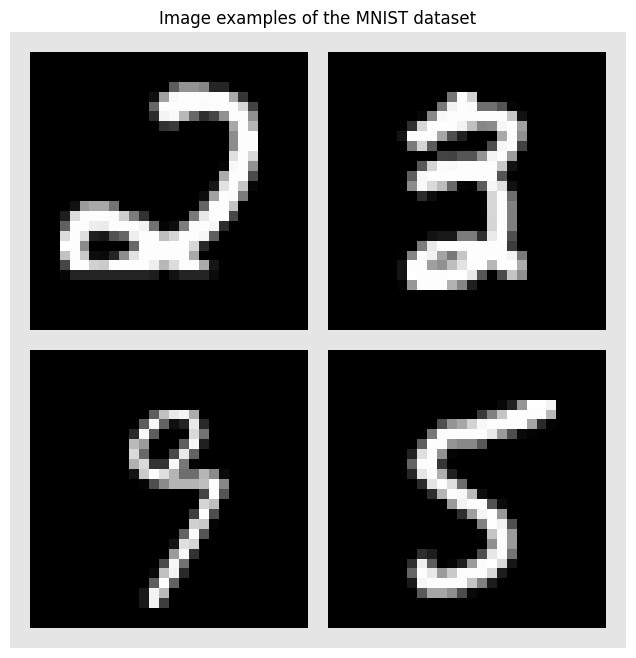

In [7]:
# Visualize some examples
NUM_IMAGES = 4
MNIST_examples = torch.stack([val_subset[idx][0] for idx in range(NUM_IMAGES)], dim=0)
img_grid = torchvision.utils.make_grid(MNIST_examples, nrow=2, normalize=True, pad_value=0.9)
img_grid = img_grid.permute(1, 2, 0)

plt.figure(figsize=(8, 8))
plt.title("Image examples of the MNIST dataset")
plt.imshow(img_grid)
plt.axis("off")
plt.show()
plt.close()

## Visualizing `img_to_patch` function

In [8]:
def img_to_patch(x, patch_size, flatten_channels=True):
    """
    Inputs:
        x - Tensor representing the image of shape [B, C, H, W]
        patch_size - Number of pixels per dimension of the patches (integer)
        flatten_channels - If True, the patches will be returned in a flattened format
                           as a feature vector instead of a image grid.
    """
    B, C, H, W = x.shape # [B, C, H, W], MNIST [B, 1, 28, 28]
    x = x.reshape(B, C, H // patch_size, patch_size, W // patch_size, patch_size) # [B, C, H', p_H, W', p_W], MNIST [B, 1, 4, 7, 4, 7]
    x = x.permute(0, 2, 4, 1, 3, 5)  # [B, H', W', C, p_H, p_W], MNIST [B, 4, 4, 1, 7, 7]
    x = x.flatten(1, 2)  # [B, H'*W', C, p_H, p_W], MNIST [B, 16, 1, 7, 7]
    if flatten_channels:
        x = x.flatten(2, 4)  # [B, H'*W', C*p_H*p_W], MNIST [B, 16, 49]
    return x

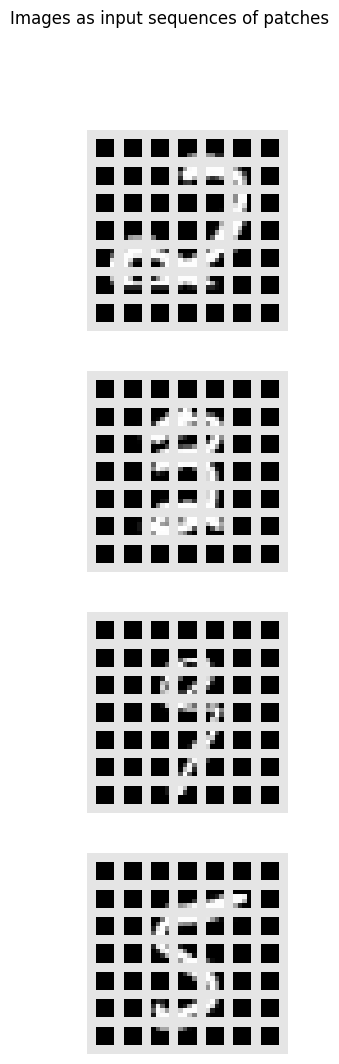

In [9]:
# Visualize the image patches
img_patches = img_to_patch(MNIST_examples, patch_size=patch_size, flatten_channels=False)

fig, ax = plt.subplots(MNIST_examples.shape[0], 1, figsize=(14, 12))
fig.suptitle("Images as input sequences of patches")
for i in range(MNIST_examples.shape[0]):
    img_grid = torchvision.utils.make_grid(img_patches[i], nrow=int(image_size/patch_size), normalize=True, pad_value=0.9)
    img_grid = img_grid.permute(1, 2, 0)
    ax[i].imshow(img_grid)
    ax[i].axis("off")
plt.show()
plt.close()

## VisionTransformer class

In [10]:
class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_heads, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of input and attention feature vectors
            hidden_dim - Dimensionality of hidden layer in feed-forward network
                         (usually 2-4x larger than embed_dim)
            num_heads - Number of heads to use in the Multi-Head Attention block
            dropout - Amount of dropout to apply in the feed-forward network
        """
        super().__init__()

        self.layer_norm_1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)
        self.layer_norm_2 = nn.LayerNorm(embed_dim)
        self.linear = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        inp_x = self.layer_norm_1(x)
        x = x + self.attn(inp_x, inp_x, inp_x)[0]
        x = x + self.linear(self.layer_norm_2(x))
        return x

In [11]:
class VisionTransformer(nn.Module):
    def __init__(
        self,
        embed_dim,
        hidden_dim,
        num_channels,
        num_heads,
        num_layers,
        num_classes,
        patch_size,
        num_patches,
        dropout=0.0,
    ):
        """
        Inputs:
            embed_dim - Dimensionality of the input feature vectors to the Transformer
            hidden_dim - Dimensionality of the hidden layer in the feed-forward networks
                         within the Transformer
            num_channels - Number of channels of the input (3 for RGB or 1 for grayscale)
            num_heads - Number of heads to use in the Multi-Head Attention block
            num_layers - Number of layers to use in the Transformer
            num_classes - Number of classes to predict
            patch_size - Number of pixels that the patches have per dimension
            num_patches - Maximum number of patches an image can have
            dropout - Amount of dropout to apply in the feed-forward network and
                      on the input encoding
        """
        super().__init__()

        self.patch_size = patch_size

        # Layers/Networks
        self.input_layer = nn.Linear(num_channels * (patch_size**2), embed_dim)
        self.transformer = nn.Sequential(
            *(AttentionBlock(embed_dim, hidden_dim, num_heads, dropout=dropout) for _ in range(num_layers))
        )
        self.mlp_head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, num_classes))
        self.dropout = nn.Dropout(dropout)

        # Parameters/Embeddings
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.randn(1, 1 + num_patches, embed_dim))

    def forward(self, x):
        # Preprocess input
        x = img_to_patch(x, self.patch_size)        # x.shape ---> batch, num_patches, (patch_size**2)
        B, T, _ = x.shape
        x = self.input_layer(x)                     # x.shape ---> batch, num_patches, embed_dim

        # Add CLS token and positional encoding
        cls_token = self.cls_token.repeat(B, 1, 1)
        x = torch.cat([cls_token, x], dim=1)        # x.shape ---> batch, num_patches+1, embed_dim
        x = x + self.pos_embedding[:, : T + 1]      # x.shape ---> batch, num_patches+1, embed_dim

        # Apply Transformer
        x = self.dropout(x)
        x = x.transpose(0, 1)                       # x.shape ---> num_patches+1, batch, embed_dim
        x = self.transformer(x)                     # x.shape ---> num_patches+1, batch, embed_dim

        # Perform classification prediction
        cls = x[0]
        out = self.mlp_head(cls)
        return out

## Initializing the model

In [13]:
model = VisionTransformer(embed_dim=embed_dim,
                          hidden_dim=hidden_dim,
                          num_heads=num_heads,
                          num_layers=num_layers,
                          patch_size=patch_size,
                          num_channels=num_channels,
                          num_patches=num_patches,
                          num_classes=num_classes,
                          dropout=dropout)

# Transfer to GPU
model.to(device)
# model_restore = None #'/content/model_20230712_211204_0'
model_restore = "checkpoints/4_49_patches_epoch_24_val_acc_97.53.pth"
if model_restore is not None and os.path.exists(model_restore):
    # model.load_state_dict(torch.load(model_restore))
    # model.restored = True
    checkpoint = torch.load(model_restore, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set the model to evaluation mode
  
  


In [14]:
model 

VisionTransformer(
  (input_layer): Linear(in_features=16, out_features=256, bias=True)
  (transformer): Sequential(
    (0): AttentionBlock(
      (layer_norm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (layer_norm_2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (linear): Sequential(
        (0): Linear(in_features=256, out_features=768, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=768, out_features=256, bias=True)
        (4): Dropout(p=0.2, inplace=False)
      )
    )
    (1): AttentionBlock(
      (layer_norm_1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (layer_norm_2): Layer

## Training

In [13]:
def save_checkpoint(model, optimizer, epoch, val_loss, val_accuracy, base_path='checkpoints'):
    # Ensure the directory exists
    os.makedirs(base_path, exist_ok=True)
    
    # Format the checkpoint filename
    checkpoint_name = f"epoch_{epoch}_val_acc_{val_accuracy:.2f}.pth"
    checkpoint_path = os.path.join(base_path, checkpoint_name)
    
    # Save the checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
    }, checkpoint_path)
    print(f"Checkpoint saved as {checkpoint_path}.")
    
criterion = nn.NLLLoss()
LR = 5e-5
NUM_EPOCHES = 25

optimizer = torch.optim.Adam(params=model.parameters(), lr=LR)

In [14]:
# setup the loss function
loss_fn = torch.nn.CrossEntropyLoss()
# setup the optimizer with the learning rate
model_optimizer = optim.Adam(model.parameters(), lr=3e-4)
# set a scheduler to decay the learning rate by 0.1 on the 100th 150th epochs
model_scheduler = optim.lr_scheduler.MultiStepLR(model_optimizer,
                                            milestones=[100, 150], gamma=0.1)

# set an empty list to plot the loss later
loss_hist = {
    "train accuracy": [],
    "train loss": [],
    "val accuracy": [],
    "val loss": [],
}
# set an initial high value for the validation loss
best_val_loss = float('inf')
patience = 5
counter = 0
checkpoint_path = "best_model.pth"


# set the timestamp to save the training model
timestamp = datetime.now().strftime('%Y%m%d_%H:%M:%S')
# Training loop
for epoch in range(25):
    model.train()
    
    epoch_train_loss = 0
        
    y_true_train = []
    y_pred_train = []
        
    for batch_idx, (img, labels) in enumerate(train_loader):
        img = img.to(device)
        labels = labels.to(device)
        
        preds = model(img)
        
        loss = criterion(preds, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        y_pred_train.extend(preds.detach().argmax(dim=-1).tolist())
        y_true_train.extend(labels.detach().tolist())
            
        epoch_train_loss += loss.item()
    
    loss_hist["train loss"].append(epoch_train_loss)
    
    # Calculate training accuracy
    total_correct_train = sum(x == y for x, y in zip(y_pred_train, y_true_train))
    total_train = len(y_pred_train)
    train_accuracy = total_correct_train * 100 / total_train
    
    loss_hist["train loss"].append(epoch_train_loss)
    loss_hist["train accuracy"].append(train_accuracy)
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0
    y_true_val = []
    y_pred_val = []
    
    with torch.no_grad():
        for img, labels in val_loader:
            img = img.to(device)
            labels = labels.to(device)
            
            preds = model(img)
            
            loss = criterion(preds, labels)
            y_pred_val.extend(preds.argmax(dim=-1).tolist())
            y_true_val.extend(labels.tolist())
            
            epoch_val_loss += loss.item()
    
    # Calculate validation accuracy
    total_correct_val = sum(x == y for x, y in zip(y_pred_val, y_true_val))
    total_val = len(y_pred_val)
    val_accuracy = total_correct_val * 100 / total_val
    
    loss_hist["val loss"].append(epoch_val_loss)
    loss_hist["val accuracy"].append(val_accuracy)
    
    # Print epoch summary
    print("-------------------------------------------------")
    print(f"Epoch: {epoch} {datetime.now().strftime('%Y%m%d_%H:%M:%S')}")
    print(f"Train Loss: {epoch_train_loss:.8f}, Train Accuracy: {train_accuracy:.2f}%")
    print(f"Val Loss: {epoch_val_loss:.8f}, Val Accuracy: {val_accuracy:.2f}%")
    print("-------------------------------------------------")
    
    # Early stopping and checkpoint saving
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0
        # Save checkpoint
        save_checkpoint(model, optimizer, epoch, epoch_val_loss, val_accuracy)
    else:
        counter += 1
        print(f"No improvement for {counter}/{patience} epochs.")
        
        if counter >= patience:
            print("Early stopping triggered.")
            break
    

-------------------------------------------------
Epoch: 0 20241129_10:58:34
Train Loss: -6738.42536534, Train Accuracy: 57.21%
Val Loss: -2960.86791611, Val Accuracy: 90.10%
-------------------------------------------------
Checkpoint saved as checkpoints/epoch_0_val_acc_90.10.pth.
-------------------------------------------------
Epoch: 1 20241129_11:00:16
Train Loss: -15823.38652134, Train Accuracy: 90.91%
Val Loss: -5146.70591164, Val Accuracy: 93.68%
-------------------------------------------------
Checkpoint saved as checkpoints/epoch_1_val_acc_93.68.pth.
-------------------------------------------------
Epoch: 2 20241129_11:01:56
Train Loss: -25293.97597694, Train Accuracy: 93.08%
Val Loss: -7710.57749557, Val Accuracy: 94.67%
-------------------------------------------------
Checkpoint saved as checkpoints/epoch_2_val_acc_94.67.pth.
-------------------------------------------------
Epoch: 3 20241129_11:03:37
Train Loss: -36264.97110367, Train Accuracy: 94.12%
Val Loss: -10620.

In [15]:
loss_hist["train loss"]

[-6738.425365336239,
 -6738.425365336239,
 -15823.386521339417,
 -15823.386521339417,
 -25293.97597694397,
 -25293.97597694397,
 -36264.97110366821,
 -36264.97110366821,
 -48515.61333847046,
 -48515.61333847046,
 -61880.01885223389,
 -61880.01885223389,
 -76281.90258026123,
 -76281.90258026123,
 -91642.30535888672,
 -91642.30535888672,
 -108022.0057220459,
 -108022.0057220459,
 -125320.07038879395,
 -125320.07038879395,
 -143556.07220458984,
 -143556.07220458984,
 -162711.09371948242,
 -162711.09371948242,
 -182824.94830322266,
 -182824.94830322266,
 -203831.5235748291,
 -203831.5235748291,
 -225798.4874267578,
 -225798.4874267578,
 -248768.64630126953,
 -248768.64630126953,
 -272545.9196472168,
 -272545.9196472168,
 -297282.26177978516,
 -297282.26177978516,
 -322873.25189208984,
 -322873.25189208984,
 -349445.88568115234,
 -349445.88568115234,
 -376967.2855529785,
 -376967.2855529785,
 -405293.70178222656,
 -405293.70178222656,
 -434656.06896972656,
 -434656.06896972656,
 -464699.624

RuntimeError: shape '[-1, 3]' is invalid for input of size 50

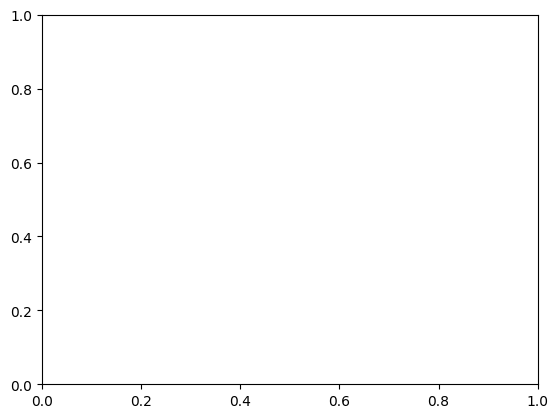

In [16]:
# plot the training loss by averaging every 3 steps
fig = plt.figure()
ax = fig.add_subplot(111)
# plot the average loss
plt.plot(torch.tensor(loss_hist["train loss"]).view(-1, 3).mean(1))
plt.title('Training loss')

In [15]:
# Set the model to evaluation mode, disabling dropout.
model.eval()
# evaluate network
acc_total = 0
with torch.no_grad():
  for imgs, labels in (test_loader):

    imgs, labels = imgs.to(device), labels.to(device)
    preds = model(imgs)
    pred_cls = preds.data.max(1)[1]
    acc_total += pred_cls.eq(labels.data).cpu().sum()

acc = acc_total.item()/len(test_loader.dataset)
print('Accuracy on vit_model set = '+str(acc))


Accuracy on vit_model set = 0.9772


In [27]:
imgs.shape

torch.Size([16, 1, 28, 28])

## Picking one test sample and running it through the first attention block

In [16]:
test_sample_index = (testset.targets==7).nonzero(as_tuple=True)[0][5].item()

In [ ]:
test_sample_index

In [17]:
# pull out one vit_model sample
img_tensor = testset.data[test_sample_index].to(device)
# convert the vit_model sample into patches
patches = img_to_patch(img_tensor.unsqueeze(0).unsqueeze(0), patch_size=patch_size)
# run the patches through the input layer to get a tensor of size embed_dim
patches = model.input_layer(patches.float())
# attach the class token and add the position embedding
transformer_input = torch.cat((model.cls_token, patches), dim=1) + model.pos_embedding
print("Input tensor to Transformer: ", transformer_input.shape)
# run the embedded vit_model image through the first attention block and squeeze the
# batch dimension because we're only using one vit_model image
transformer_input_expanded = model.transformer[0].linear[0](transformer_input).squeeze(0)
print("transformer_input_expanded shape: ", transformer_input_expanded.shape)

Input tensor to Transformer:  torch.Size([1, 50, 256])
transformer_input_expanded shape:  torch.Size([50, 768])


In [18]:
# reshape the output of the first attention block to be of size (num_patches+1, 3, num_heads, -1)
qkv = transformer_input_expanded.reshape(num_patches+1, 3, num_heads, -1)
print("qkv shape: ", qkv.shape)
# pull the query matrix and permute the dimensions to be (8 heads, 17 patches, 32 channels)
# do the same for the key matrix
q = qkv[:, 0].permute(1, 0, 2)
k = qkv[:, 1].permute(1, 0, 2)
print("q shape: ", q.shape)
print("k shape: ", k.shape)
kT = k.permute(0, 2, 1)
# The result of multiplying q @ kT is a squared matrix 17 by 17 showing how each
# patch is "paying attention" to every other patch
attention_matrix = q @ kT
print("attention matrix: ", attention_matrix.shape)

qkv shape:  torch.Size([50, 3, 8, 32])
q shape:  torch.Size([8, 50, 32])
k shape:  torch.Size([8, 50, 32])
attention matrix:  torch.Size([8, 50, 50])


In [19]:
# Average the attention weights across all heads by taking the mean along
# the first dimension
attention_matrix_mean = torch.mean(attention_matrix, dim=0)
print("attention matrix mean: ", attention_matrix_mean.shape)

# To account for residual connections, we add an identity matrix to the
# attention matrix and re-normalize the weights.
# Please refer to the attention rollout paper: https://arxiv.org/abs/2005.00928
residual_att = torch.eye(attention_matrix_mean.size(1)).to(device)
aug_att_mat = attention_matrix_mean + residual_att
print("augmented attention matrix: ", aug_att_mat.shape)
aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)
print("normalized augmented attention matrix: ", aug_att_mat.shape)

attention matrix mean:  torch.Size([50, 50])
augmented attention matrix:  torch.Size([50, 50])
normalized augmented attention matrix:  torch.Size([50, 50])


## Plotting attention
Now we have a normalized squared matrix of size $17\times 17$. When plotting the first column is the class token. The remaining $16$ columns will be reshaped into a $4\times 4$ matrix, ordered in a way where each patch has its position in the image. For better visualization, we'll use `interpolate` function to resize the $4\times 4$ matrix to $28\times 28$.

attn_heatmap:  tensor([[ 1.7277e-03, -7.7803e-04, -4.1831e-05, -2.1118e-03,  3.6650e-04,
         -2.3287e-03, -1.0186e-03],
        [-1.8472e-03,  2.3816e-04, -2.6752e-03, -8.4692e-02, -2.8679e-02,
         -2.1682e-05,  2.7560e-03],
        [-2.6043e-04,  8.7846e-02,  1.1114e-01, -4.3400e-02,  1.5889e-01,
          1.6563e-04,  9.4041e-04],
        [ 1.1745e-03, -1.2753e-03,  2.5108e-03, -6.5924e-03,  8.3830e-02,
          3.8407e-03, -2.5930e-03],
        [ 7.9493e-04, -1.0041e-03,  1.7166e-03,  9.8085e-02,  4.2941e-01,
          8.4637e-02, -2.2100e-03],
        [-8.1359e-05,  2.6213e-03, -4.2522e-03,  8.9296e-02,  2.7181e-03,
         -6.1064e-03, -9.0054e-04],
        [ 4.9343e-03,  1.0955e-03, -5.3638e-02,  5.7698e-02,  2.6867e-03,
          9.7148e-04, -3.0132e-03]], grad_fn=<ViewBackward0>)
attn_heatmap_resized:  torch.Size([28, 28, 1])


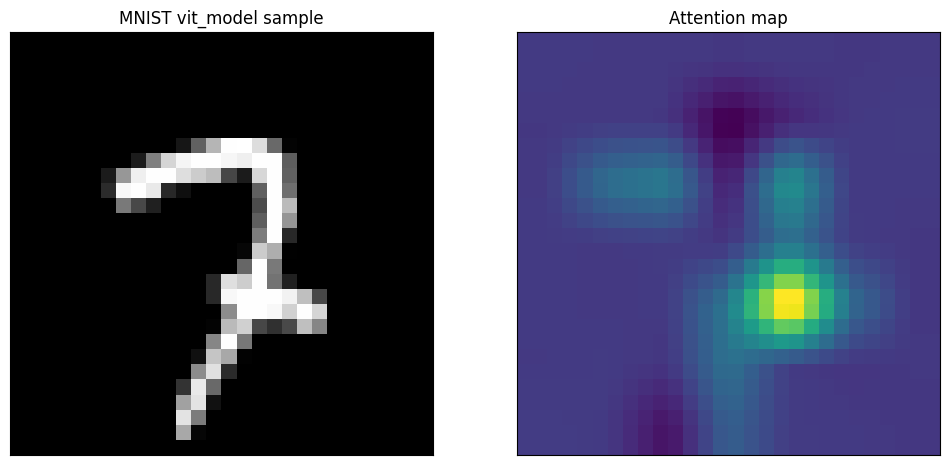

In [20]:
attn_heatmap = aug_att_mat[0, 1:].reshape((int(image_size/patch_size), int(image_size/patch_size)))
print("attn_heatmap: ", attn_heatmap)
attn_heatmap_resized = F.interpolate(attn_heatmap.unsqueeze(0).unsqueeze(0), [image_size, image_size], mode='bilinear').view(28, 28, 1)
print("attn_heatmap_resized: ", attn_heatmap_resized.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
img = np.asarray(img_tensor.cpu())
ax1.imshow(img, cmap='gray')
ax1.set_title('MNIST vit_model sample')
ax1.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
               labelbottom=False, labeltop=False, labelleft=False, labelright=False)

ax2.imshow(attn_heatmap_resized.detach().cpu().numpy())
ax2.set_title('Attention map')
ax2.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
                labelbottom=False, labeltop=False, labelleft=False, labelright=False)

In [29]:
def single_attention_rollout(img_tensor):

    # with (torch.no_grad()):  # Disable gradient calculation
    # convert the vit_model sample into patches
    print(f"img_tensor shape: {img_tensor.shape}")
    print(f"img_tensor.unsqueeze(0).unsqueeze(0) shape: {img_tensor.unsqueeze(0).unsqueeze(0).shape}")
    patches = img_to_patch(img_tensor.unsqueeze(0).unsqueeze(0), patch_size=patch_size)  # [B, num_patches,  patch_size²] [10, 49, 16]
    print("""patches shape: """, patches.shape)
    
    # run the patches through the input layer to get a tensor of size embed_dim
    patches = model.input_layer(patches.float()) # [B, num_patches, embed_dim] [10, 49, 256]
    # attach the class token and add the position embedding
    # cls_token_expanded = self.model.cls_token.expand(patches.shape[0], -1, -1) # [1, 1, 256]
    transformer_input = torch.cat((model.cls_token, patches), dim=1) + model.pos_embedding # [1, 50, 256]

    # run the embedded vit_model image through the first attention block and squeeze the
    # batch dimension because we're only using one vit_model image
    transformer_input_expanded = model.transformer[0].linear[0](transformer_input).squeeze(0) # [10, 50, 768]
    # reshape the output of the first attention block to be of size (bs, num_patches+1, 3, num_heads, -1) [10, 50, 3, 8, 32]
    qkv = transformer_input_expanded.reshape(num_patches+1, #  Sequence length (patches + class token)
                                             3, # Query, Key, Value
                                             num_heads,
                                             -1)  # Head size

    # pull the query matrix and permute the dimensions to be (8 heads, 17 patches, 32 channels)
    # do the same for the key matrix
    q = qkv[:, 0].permute(1, 0, 2)
    k = qkv[:, 1].permute(1, 0, 2)
    print("q shape: ", q.shape)
    print("k shape: ", k.shape)
    kT = k.permute(0, 2, 1)
    # The result of multiplying q @ kT is a squared matrix 17 by 17 showing how each
    # patch is "paying attention" to every other patch
    attention_matrix = q @ kT
    print("attention matrix: ", attention_matrix.shape)

    attention_matrix_mean = torch.mean(attention_matrix, dim=0)
    print("attention matrix mean: ", attention_matrix_mean.shape)

    # To account for residual connections, we add an identity matrix to the
    # attention matrix and re-normalize the weights.
    # Please refer to the attention rollout paper: https://arxiv.org/abs/2005.00928
    residual_att = torch.eye(attention_matrix_mean.size(1)).to(device)
    aug_att_mat = attention_matrix_mean + residual_att
    print("augmented attention matrix: ", aug_att_mat.shape)
    aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)
    print("normalized augmented attention matrix: ", aug_att_mat.shape)


    # Skip the [CLS] token and reshape attention to patch grid
    attn_heatmap = aug_att_mat[ 0, 1:].reshape(
        (int(image_size / patch_size),
         int(image_size / patch_size))
    )  # Shape: [patch_grid, patch_grid]

    # Normalize the attention heatmap
    # attn_heatmap = (attn_heatmap - attn_heatmap.min()) / (attn_heatmap.max() - attn_heatmap.min())

    # Resize attention heatmap to original image size using bilinear interpolation
    attn_heatmap_resized = F.interpolate(
        attn_heatmap.unsqueeze(0).unsqueeze(0),  # Add batch and channel dimensions
        size=[image_size, image_size],
        mode='bilinear',
        #align_corners=False
    ).squeeze().view(image_size, image_size, 1)  # Shape: [image_size, image_size, 1]

    attn_heatmap_resized = attn_heatmap_resized.detach().cpu().numpy()

    return attn_heatmap_resized

In [30]:
attn_heatmap_resized2 = single_attention_rollout(img_tensor)

img_tensor shape: torch.Size([28, 28])
img_tensor.unsqueeze(0).unsqueeze(0) shape: torch.Size([1, 1, 28, 28])
patches shape:  torch.Size([1, 49, 16])
q shape:  torch.Size([8, 50, 32])
k shape:  torch.Size([8, 50, 32])
attention matrix:  torch.Size([8, 50, 50])
attention matrix mean:  torch.Size([50, 50])
augmented attention matrix:  torch.Size([50, 50])
normalized augmented attention matrix:  torch.Size([50, 50])


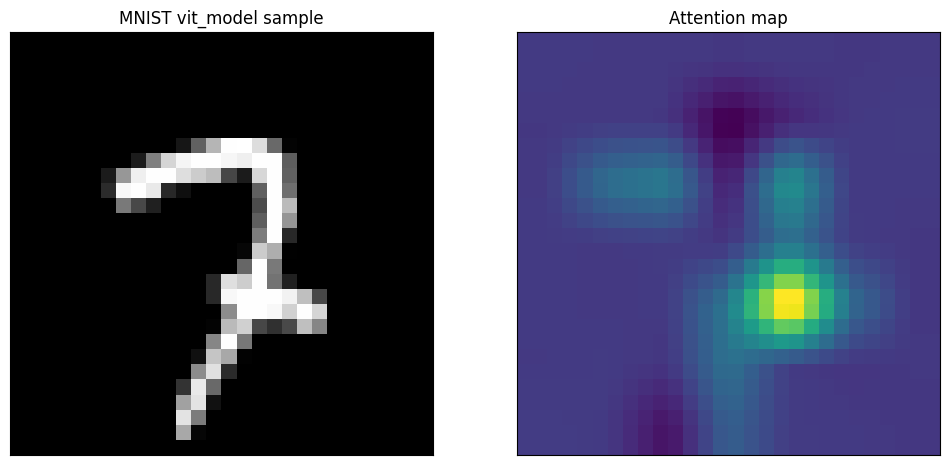

In [31]:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
img = np.asarray(img_tensor.cpu())
ax1.imshow(img, cmap='gray')
ax1.set_title('MNIST vit_model sample')
ax1.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
               labelbottom=False, labeltop=False, labelleft=False, labelright=False)

ax2.imshow(attn_heatmap_resized2)
ax2.set_title('Attention map')
ax2.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False,
                labelbottom=False, labeltop=False, labelleft=False, labelright=False)

In [33]:
img_tensor

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   